# Weather Prediction with Time-Series
* In this notebook, we are going to predict weather' situations with CNN-LSTM.
> - Tempreature is our target
> - Others will be our features

## Load and Explore Dataset

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [153]:
data = pd.read_csv("weatherHistory.csv")
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [154]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [155]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
Apparent Temperature (C),96453.0,10.855029,10.696847,-27.716667,2.311111,12.0000,18.838889,39.344444
Humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


* Convert "Formatted Date" datatype from object to datetime

In [156]:
data["Formatted Date"] = pd.to_datetime(data["Formatted Date"])
data["Formatted Date"].head()

C:\Users\PC\AppData\Local\Temp\ipykernel_3948\2773602134.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["Formatted Date"] = pd.to_datetime(data["Formatted Date"])


0    2006-04-01 00:00:00+02:00
1    2006-04-01 01:00:00+02:00
2    2006-04-01 02:00:00+02:00
3    2006-04-01 03:00:00+02:00
4    2006-04-01 04:00:00+02:00
Name: Formatted Date, dtype: object

In [157]:
data.set_index("Formatted Date",inplace = True)

In [158]:
data.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
Formatted Date,,,,,,,,,,,
2006-04-01 00:00:00+02:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
2006-04-01 01:00:00+02:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2006-04-01 02:00:00+02:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
2006-04-01 03:00:00+02:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
2006-04-01 04:00:00+02:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [159]:
data.columns

Index(['Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Loud Cover', 'Pressure (millibars)',
       'Daily Summary'],
      dtype='object')

* Remove some variables

In [160]:
data.drop(columns =["Summary","Precip Type","Daily Summary"],inplace = True)

In [161]:
data.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
Formatted Date,,,,,,,,
2006-04-01 00:00:00+02:00,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13
2006-04-01 01:00:00+02:00,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63
2006-04-01 02:00:00+02:00,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94
2006-04-01 03:00:00+02:00,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41
2006-04-01 04:00:00+02:00,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51


* bring columns'name in an appropriate shape

In [162]:
data.columns = [col.strip().lower().replace(" ","_").replace("(","").replace(")","") for col in data.columns]

In [163]:
data.columns

Index(['temperature_c', 'apparent_temperature_c', 'humidity',
       'wind_speed_km/h', 'wind_bearing_degrees', 'visibility_km',
       'loud_cover', 'pressure_millibars'],
      dtype='object')

* Missing Value

In [164]:
data.isnull().sum()

temperature_c             0
apparent_temperature_c    0
humidity                  0
wind_speed_km/h           0
wind_bearing_degrees      0
visibility_km             0
loud_cover                0
pressure_millibars        0
dtype: int64

In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96453 entries, 2006-04-01 00:00:00+02:00 to 2016-09-09 23:00:00+02:00
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   temperature_c           96453 non-null  float64
 1   apparent_temperature_c  96453 non-null  float64
 2   humidity                96453 non-null  float64
 3   wind_speed_km/h         96453 non-null  float64
 4   wind_bearing_degrees    96453 non-null  float64
 5   visibility_km           96453 non-null  float64
 6   loud_cover              96453 non-null  float64
 7   pressure_millibars      96453 non-null  float64
dtypes: float64(8)
memory usage: 6.6+ MB


C:\Users\PC\AppData\Local\Temp\ipykernel_3948\1336748264.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


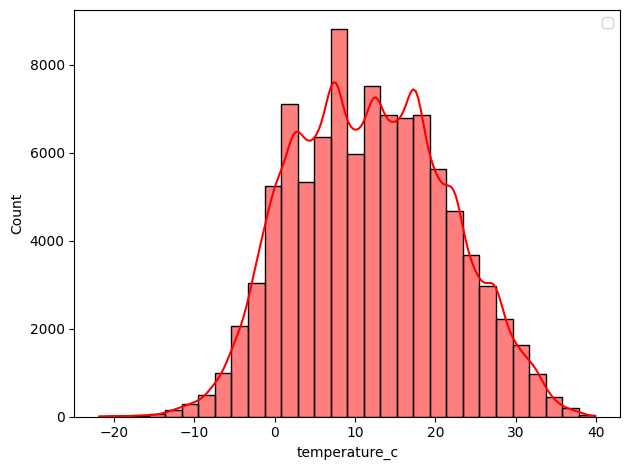

In [166]:
plt.figure()
sns.histplot(data["temperature_c"],color = "red",kde = True,bins=30)
plt.legend()
plt.tight_layout()
plt.show()

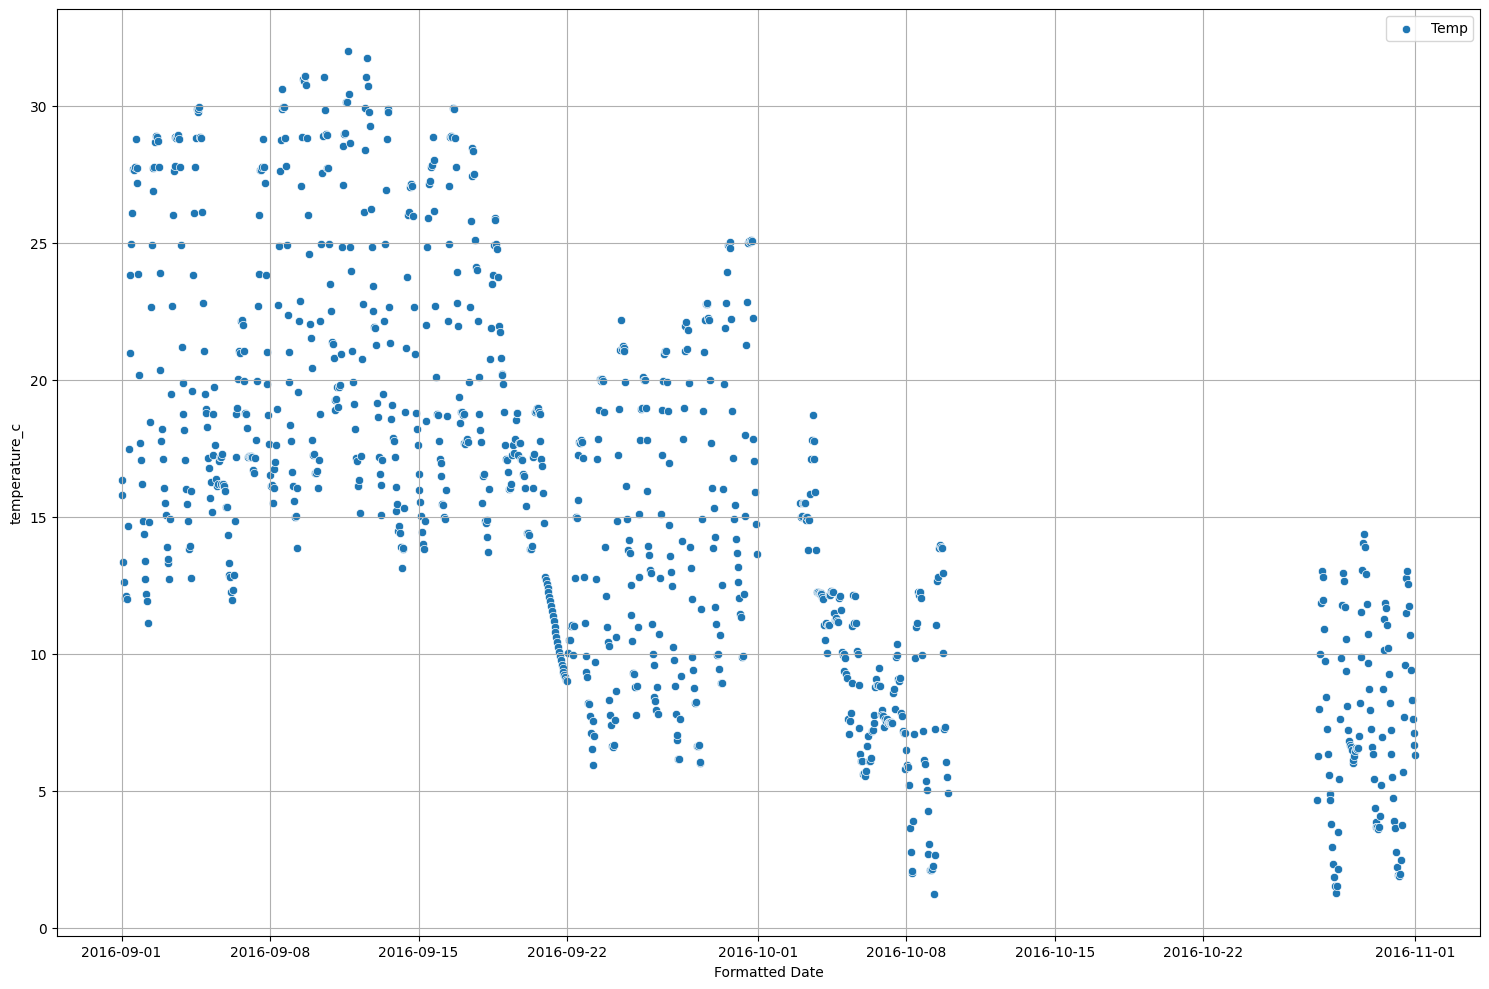

In [167]:
plt.figure(figsize=(15,10))
sns.scatterplot(data["temperature_c"].iloc[-1000:],label = "Temp")
plt.tight_layout()
plt.grid(True)
plt.legend()

* Preprocessing

In [168]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [169]:
data.columns

Index(['temperature_c', 'apparent_temperature_c', 'humidity',
       'wind_speed_km/h', 'wind_bearing_degrees', 'visibility_km',
       'loud_cover', 'pressure_millibars'],
      dtype='object')

In [170]:
target = ["temperature_c"]
features = ['apparent_temperature_c', 'humidity',
       'wind_speed_km/h', 'wind_bearing_degrees', 'visibility_km',
        'pressure_millibars']

In [171]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

In [172]:
data_z = data[features + target].copy()
z_scores = np.abs(zscore(data_z))
z_scores

array([[0.32403547, 0.79347043, 0.47863499, ..., 1.30697578, 0.10168518,
        0.25759902],
       [0.3390971 , 0.63999555, 0.49959388, ..., 1.30697578, 0.1059598 ,
        0.26981351],
       [0.13810226, 0.79347043, 0.99547337, ..., 1.09958576, 0.10861007,
        0.26748694],
       ...,
       [1.04553403, 0.89475327, 0.2642411 , ..., 1.37226523, 0.10621628,
        1.0580761 ],
       [0.99723295, 0.6901201 , 0.04067964, ..., 1.37226523, 0.10869557,
        1.00398335],
       [0.89595648, 0.6389618 , 0.71369278, ..., 1.23400522, 0.11049091,
        0.89056308]], shape=(96453, 7))

In [173]:
data_clean = data_z[(z_scores<3).all(axis = 1)]

In [174]:
data_clean.dropna(inplace = True)

C:\Users\PC\AppData\Local\Temp\ipykernel_3948\3702134204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean.dropna(inplace = True)


In [175]:
data_clean.head()

,apparent_temperature_c,humidity,wind_speed_km/h,wind_bearing_degrees,visibility_km,pressure_millibars,temperature_c
Formatted Date,,,,,,,
2006-04-01 00:00:00+02:00,7.388889,0.89,14.1197,251.0,15.8263,1015.13,9.472222
2006-04-01 01:00:00+02:00,7.227778,0.86,14.2646,259.0,15.8263,1015.63,9.355556
2006-04-01 02:00:00+02:00,9.377778,0.89,3.9284,204.0,14.9569,1015.94,9.377778
2006-04-01 03:00:00+02:00,5.944444,0.83,14.1036,269.0,15.8263,1016.41,8.288889
2006-04-01 04:00:00+02:00,6.977778,0.83,11.0446,259.0,15.8263,1016.51,8.755556


In [176]:
X = data_clean[features]
y = data_clean[target]

In [177]:
X_scaled = scaler_x.fit_transform(X)

In [178]:
X_seq,y_seq = [],[]
sequence_length = 24
for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X[i : i + sequence_length])
    y_seq.append(y.values[i + sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


In [179]:
split = int(len(X_seq)*0.8)
X_train = X_seq[:split]
X_test = X_seq[split:]
y_train = y_seq[:split]
y_test  = y_seq[split:]

In [180]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((75112, 24, 6), (18779, 24, 6), (75112, 1), (18779, 1))

* CNN-LSTM

In [208]:
input_shape = X_train.shape[1:]
# CNN-LSTM
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv1D(filters=64,kernel_size=3,activation = "relu",input_shape = input_shape))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2)) # for overfitting
model.add(tf.keras.layers.LSTM(64,return_sequences=False))
model.add(tf.keras.layers.Dense(1))

# compile model
model.compile(loss = tf.keras.losses.MeanSquaredError(),
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ["mae"])

# train the model
history = model.fit(X_train,y_train,epochs = 5,batch_size = 32,
          validation_data = (X_test,y_test))

Epoch 1/5


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2348/2348 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 13.6281 - mae: 2.4881 - val_loss: 105.3722 - val_mae: 9.1644
Epoch 2/5
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5.4722 - mae: 1.7885 - val_loss: 62.8901 - val_mae: 7.2844
Epoch 3/5
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5.0581 - mae: 1.7128 - val_loss: 56.0681 - val_mae: 5.9641
Epoch 4/5
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 4.7814 - mae: 1.6590 - val_loss: 30.2196 - val_mae: 4.6270
Epoch 5/5
2348/2348 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 4.3303 - mae: 1.5689 - val_loss: 11.5042 - val_mae: 2.9602


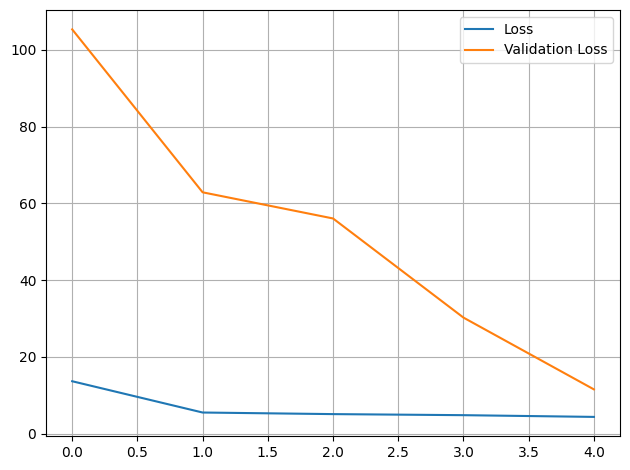

In [209]:
plt.figure()
plt.plot(history.history["loss"],label = "Loss")
plt.plot(history.history["val_loss"],label = "Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

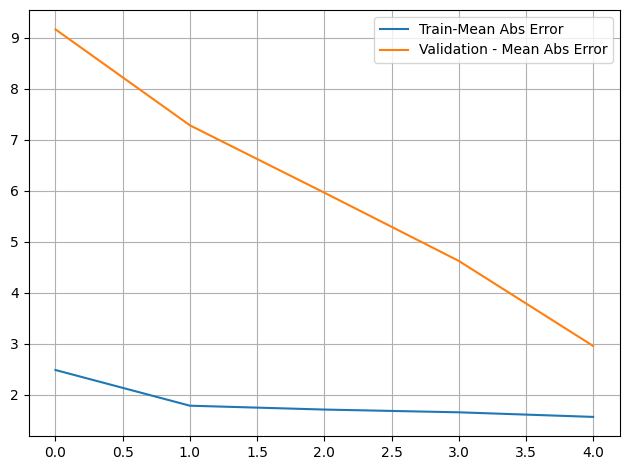

In [210]:
plt.figure()
plt.plot(history.history["mae"],label = "Train-Mean Abs Error")
plt.plot(history.history["val_mae"],label = "Validation - Mean Abs Error")
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

In [211]:
# save model
model.save("cnn-lstm-model.h5")

In [212]:
y_pred = model.predict(X_test)
y_pred

587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


array([[21.445065],
       [21.558979],
       [21.036488],
       ...,
       [25.800419],
       [23.663548],
       [22.905981]], shape=(18779, 1), dtype=float32)

In [213]:
y_pred = y_pred.flatten()

In [214]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
mae

2.960171549053911

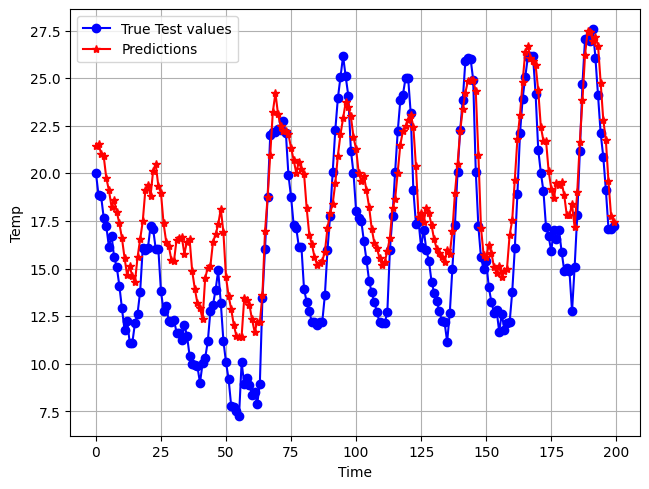

In [215]:
plt.figure()
plt.plot(y_test[:200],label = "True Test values",marker = "o",c = "blue")
plt.plot(y_pred[:200],label = "Predictions",marker = "*",c = "red")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Temp")
plt.show()